In [1]:
import networkx as nx
import numpy as np
import fugu
from fugu import Scaffold, Brick
from fugu.bricks import Vector_Input
from fugu.backends import snn_Backend

In [ ]:
# Sample module to show how to add learning to the edges directly
class learning_brick(Brick):
    def __init__(self, name=None):
        super().__init__()
        self.is_built = False
        self.metadata = {'D':1}  
        self.name = name
        self.supported_codings = fugu.input_coding_types
    
    def build(self,
             graph,
             metadata,
             control_nodes,
             input_lists,
             input_codings):
        output_codings = [input_codings[0]]
        
        new_complete_node_name = self.name + '_complete'
        graph.add_node(new_complete_node_name,
                      index = -1,
                      threshold = 0.0,
                      decay =0.0,
                      p=1.0,    
                      potential=0.0)
        graph.add_edge(control_nodes[0]['complete'], new_complete_node_name,weight=1.0,delay=1)
        
        learning_node_name = self.name + '_0'
        graph.add_node(learning_node_name,
                       index=0,
                       threshold=1.0,
                       decay=1.0,
                       p=1.0,
                       potential=0.0
                      )
        for input_neuron in input_lists[0]:
            graph.add_edge(input_neuron,
                          learning_node_name,
                          weight=0.5,
                          delay=1.0, learning_rule="STDP", learning_params=None)
        self.is_built=True
        
        output_lists = [[learning_node_name]]
        
        return (graph,
               self.metadata,
                [{'complete':new_complete_node_name}],
                output_lists,
                output_codings
               )

In [2]:
from fugu.scaffold import ChannelSpec, PortSpec, PortData, PortUtil


class Projection(Brick):
    def __init__(self, 
                 name=None, 
                 output_size = 10,
                 connection_sparsity = 0.1,
                 learning = 1,
                 ):
        super().__init__()
        self.output_size = output_size
        self.connection_sparsity = connection_sparsity
        self.learning = learning
        
        #The brick hasn't been built yet.
        self.is_built = False
        #We just store the name passed at construction.
        self.name = name
        #For this example, we'll let any input coding work even though the answer might not make sense.
        self.supported_codings = fugu.input_coding_types
    # This method describes the input ports that any RandomProjection brick expects.
    # This includes the actual data values, as well as a signal indicating when the
    # source of input is ready for us to procss the data. Since we execute in a single
    # cycle, this signal is simply passed on to the next brick (see build2() later).
    @classmethod
    def input_ports(cls) -> dict[str, PortSpec]:
        port = PortSpec(name='input', minimum=1, maximum=1)  # Must be exactly 1 port, no more, no less.
        port.channels['data']     = ChannelSpec(name='data')
        port.channels['complete'] = ChannelSpec(name='complete')
        return {port.name: port}

    # This method describes the output port that any RandomProjection brick provides.
    # This includes the data and the 'complete' signal that we pass on.
    @classmethod
    def output_ports(cls) -> dict[str, PortSpec]:
        port = PortSpec(name='output')
        port.channels['data']     = ChannelSpec(name='data', coding=['Raster'])
        port.channels['complete'] = ChannelSpec(name='complete')
        return {port.name: port}

    # This method does the actual network construction. It reads the input ports, wires up
    # some neurons, and provides their identities via the output port.
    def build2(self, graph, inputs: dict[str, PortData] = {}):
        """
        Build RandomProjection brick.
        Raises:
            ValueError: If != 1 inputs.  Only 1 inputs is supported.  Error if unsupported mode.
        """
        # Expect two inputs
        if len(inputs) != 1:
            raise ValueError('Only one input supported.')

        # Set up convenience variables for accessing our working ports.
        input1 = inputs['input']  # Unpack the input ports.
        output_ports_dictionary = PortUtil.make_ports_from_specs(Projection.output_ports())  # Create our output port(s).
        output_port = output_ports_dictionary['output']  # Unpack the only actual output port.
        output_data = output_port.channels['data']  # Unpack the data channel where our main result goes.

        # Keep the same coding as input 0 for the output
        # This is an arbitrary decision at this point.
        # Generally, your brick will impart some coding, but that isn't the case here.
        output_data.spec.coding = input1.channels['data'].spec.coding

        # Build the computational graph.
        # This is the heart of the brick.
        input_neurons = input1.channels['data'].neurons
        for postsynaptic_neuron_idx in range(self.output_size):
            # Generate a name for the new neuron, which also happens to be an output neuron.
            projection_neuron = self.generate_neuron_name(str(postsynaptic_neuron_idx))
            output_data.neurons.append(projection_neuron)
            # Create the neuron.
            graph.add_node(projection_neuron,
                           index=0,
                           threshold=-0.055,
                           reset_voltage=-0.065,
                           leakage_constant = 1.0,
                           voltage = -0.065,
                           decay=1.0,
                           p=1.0)
            #Connect based on random draw:
            for presynaptic_neuron in input_neurons:
                if np.random.rand() < self.connection_sparsity: #random draw
                    graph.add_edge(presynaptic_neuron, 
                                   projection_neuron,
                                   weight=0.04,  #You probably want to use a "real" weight, but we'll just use 0.5
                                   delay=1, learning_rule="STDP", learning_params=None) if self.learning else graph.add_edge(presynaptic_neuron, 
                                   projection_neuron,
                                   weight=0.04,
                                   delay=1)

        # Hook up the signals.
        # We just forward the incoming signal with one cycle of delay.
        complete_node_name = self.generate_neuron_name('complete')
        output_port.channels['complete'].neurons = [complete_node_name]
        graph.add_node( complete_node_name,
                        index=-1,
                        threshold=-0.055,
                        reset_voltage=-0.065,
                        leakage_constant = 1.0,
                        voltage = -0.065,
                        decay=1.0,
                        p=1.0)
        graph.add_edge(input1.channels['complete'].neurons[0],
                       complete_node_name,
                       weight=1.0,
                       delay=1)

        self.is_built = True
        return output_ports_dictionary


In [3]:
def plot_spike_raster(scaffold, results):
    import matplotlib.pyplot as plot
    num_elements=scaffold.graph.number_of_nodes()
    print('Number of neurons: ', num_elements)
    results.plot.scatter(x='time', y='neuron_number', title="Spike Raster")
    plot.show()
    
def plot_scaffold_graph(scaffold):
    edge_weights = [scaffold.graph.edges[v]['weight'] for v in scaffold.graph.edges()]
    nx.draw_networkx(scaffold.graph, 
                 with_labels = False, 
                 pos = nx.spring_layout(scaffold.graph),
                 edge_color = edge_weights,
                 node_size = 100)

In [4]:
from fugu.simulators.SpikingNeuralNetwork.input_encoding import InputEncoding
base_image = np.array(
        [
            [0, 0, 1, 0, 0],
            [0, 1, 0, 1, 0],
            [1, 0, 0, 0, 1],
            [0, 1, 0, 1, 0],
            [0, 0, 1, 0, 0],
        ]
    )
noisy = 0
np.random.seed(1)
noise = np.random.rand(5, 5)
noise_image = base_image + noise * 0.2
noise_image[noise_image > 1] = 1
image = noise_image if noisy else base_image
image = image.flatten()
num_input_neurons = 25
n_bins = 100
input_spikes = np.zeros((num_input_neurons, n_bins))
for in_neuron in range(num_input_neurons):
    input_stream = InputEncoding("Poisson", in_stream = np.array([image[in_neuron]]), frequency = 100, bins = n_bins).get_iterable()
    input_spikes[in_neuron, :] = input_stream
# print(input_spikes.shape, input_spikes[0])


In [ ]:
from collections import deque

class Vector_Input(InputBrick):
    """
    Class to handle a vector of spiking input. Inherits from InputBrick
    Construtor for this brick.
        Args:
            spikes (array): A numpy array of which neurons should spike at which times
            time_dimension: Time dimesion is included as dimension -1
            coding: Coding type to be represented.
            batchable: True if input should represent static data; currently True is the only supported mode.
            name (str): Name of the brick.  If not specified, a default will be used.  Name should be unique.
    """
    def __init__(
        self,
        spikes,
        time_dimension=False,
        coding='Undefined',
        batchable=True,
        name="VectorInput",
    ):

        super(Vector_Input, self).__init__(name)
        self.vector = np.array(spikes)
        self.shape = self.vector.shape[0:-1] if time_dimension else self.vector.shape
        self.coding = coding
        self.time_dimension = time_dimension
        self.is_built = False
        self.batchable = batchable
        self.name = name
        self.index_map = None
        self.supported_codings = []
        self.metadata = {'D': 0}
        self.current_time = 0

    def __iter__(self):
        self.current_time = 0
        return self

    def __next__(self):
        if self.vector.shape[-1] > self.current_time:
            self.current_time += 1
            this_time_vector = self.vector[..., self.current_time - 1]
            local_idxs = np.array(np.where(this_time_vector))
            num_spikes = len(local_idxs[0])
            global_idxs = deque()
            for spike in range(num_spikes):
                idx_to_build = deque()
                for dimension in range(len(local_idxs)):
                    idx_to_build.append(local_idxs[dimension][spike])
                global_idxs.append(tuple(idx_to_build))
            spiking_neurons = [
                self.generate_neuron_name(str(idx)) for idx in global_idxs
            ]
            return spiking_neurons
        else:
            raise StopIteration

    next = __next__

    def set_properties(self, properties={}):
        new_vector = np.array(properties['spike_vector'])
        if 'time_dimension' not in properties or properties['time_dimension']:
            new_vector = np.expand_dims(new_vector, len(new_vector.shape))
        if new_vector.shape != self.vector.shape:
            raise ValueError(
                "Dimensions of new spike vector ({}) does not match expected ({})"
                .format(
                    new_vector.shape,
                    self.vector.shape,
                ), )
        else:
            self.vector = new_vector
            self.current_time = 0
        return None

    def get_input_value(self, t=None):
        warn(
            "get_input_value is deprecated and will be removed from later versions."
        )
        warn("Please ensure that your backend is up-to-date.")
        if t is None:
            return self.vector
        else:
            assert type(t) is int
            return self.vector[..., t:t + 1][..., -1]

    @classmethod
    def input_ports(cls) -> dict[str, PortSpec]:
        return {}

    @classmethod
    def output_ports(cls) -> dict[str, PortSpec]:
        port = PortSpec(name='output')
        port.channels['data']     = ChannelSpec(name='data')
        port.channels['begin']    = ChannelSpec(name='begin')
        port.channels['complete'] = ChannelSpec(name='complete')
        return {port.name: port}

    def build2(self, graph, inputs: dict[str, PortData] = {}):
        """
        Build spike input brick.

        Args:
            graph: networkx graph to define connections of the computational graph
            metadata: dictionary to define the shapes and parameters of the brick
            control_nodes: list of dictionary of auxillary nodes.
                Expected keys:
                    'complete' - A list of neurons that fire when the brick is done
            input_lists: list of nodes that will contain input
            input_coding: list of input coding formats

        Returns:
            graph: graph of a computational elements and connections
            output_shape, output_coding, layer, D: dictionary of output parameters (shape, coding, layers, depth, etc)
            complete_node, begin_node: list of dictionary of control nodes ('complete')
            output_lists (list): list of output
            output_codings (list): list of coding formats of output

        """

        if not self.time_dimension:
            self.vector = np.expand_dims(self.vector, len(self.vector.shape))

        #print(f"Current vector: {self.vector}")

        result = PortUtil.make_ports_from_specs(Vector_Input.output_ports())
        output = result['output']
        data = output.channels['data']
        data.spec.coding = self.coding
        data.spec.shape  = self.shape

        begin_node    = self.generate_neuron_name("begin")
        complete_node = self.generate_neuron_name("complete")
        output.channels['begin']   .neurons = [begin_node]
        output.channels['complete'].neurons = [complete_node]
        vector_size = len(self.vector) * len(self.vector.shape)
        graph.add_node(begin_node,
                       index=-1,
                        threshold=-0.055,
                        voltage=-0.065,
                       decay=0.0,
                       p=1.0,
                       potential=0.1)
        time_length = self.vector.shape[-1]
        if time_length == 1:
            graph.add_node(complete_node,
                           index=-1,
                           threshold=-0.055,
                           voltage=-0.065,
                           decay=0.0,
                           p=1.0,
                           potential=0.1)
        else:
            graph.add_node(complete_node,
                           index=-1,
                           threshold=0.5,
                           decay=0.0,
                           p=1.0,
                           potential=0.0)
            graph.add_edge(begin_node,
                           complete_node,
                           weight=1.0,
                           delay=time_length - 1)

        self.index_map = np.ndindex(self.vector.shape[:-1])
        for i, index in enumerate(self.index_map):
            neuron_name = self.generate_neuron_name(str(index))
            graph.add_node(neuron_name,
                           index=index,
                           threshold=0.0,
                           decay=0.0,
                           p=1.0)
            data.neurons.append(neuron_name)

        self.is_built = True
        return result

def _convert_base_p(arr, p=2, bits=8, time_dimension = False, collapse_binary=True):
    if p > 2:
        collapse_binary = False
    max_value = np.max(arr)
    if max_value > p**bits - 1:
        raise ValueError("Max value of {} exceeded.".format(p**bits - 1))
    min_value = np.min(arr)
    if min_value < 0:
        raise ValueError("Inputs should be positive.")
    x = None
    for bit_no in range(bits):
        x_i = None
        mod = np.mod(np.floor(arr/(p**bit_no)), p)
        for p_i in range(p):
            this_slice = (mod==p_i).astype(np.int8)
            this_slice = np.expand_dims(this_slice, -1)
            this_slice = np.expand_dims(this_slice, -1)
            if p_i == 0:
                x_i = this_slice
            else:
                x_i = np.concatenate([x_i,this_slice], axis=-1)
        if collapse_binary:
            x_i = x_i[...,1]
        if bit_no == 0:
            x = x_i
        else:
            concat_axis = -1 if collapse_binary else -2
            x = np.concatenate([x, x_i], axis=concat_axis)
    if time_dimension:
        time_axis = -2 if collapse_binary else -3
        x = np.moveaxis(x, time_axis, -1)
    return x


In [5]:
backend = snn_Backend()
backend_args = {}
backend_args['record'] = 'all'

Edge weights:  [1.0, 1.0, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04]
Updated weight: 0.05970445533548509
Updated weight: 0.05970445533548509
Updated weight: 0.05980198673306755
Updated weight: 0.06931234972700832
Updated weight: 0.06940988112459079
Updated weight: 0.07940891067097017
Updated weight: 0.07882752646043328
Updated weight: 0.08892120491597731
Updated weight: 0.08796683831314557
Updated weight: 0.09815236837984367
Updated weight: 0.05980198673306755
Updated weight: 0.09701521249350517
Updated weight: 0.10911433646007586
Updated weight: 0.05980198673306755
Updated weight: 0.10729168023255596
Updated weight: 0.05951229424500715
Updated weight: 0.10570879484749324
Updated weight: 0.06921963206891005
Updated weight: 0.11607263454176157
Updated weight: 0.06892993958084964
Updated weight: 0.0796039734661351
Updated weight: 0.11431587461174382
Updated weight: 0.128916323193143

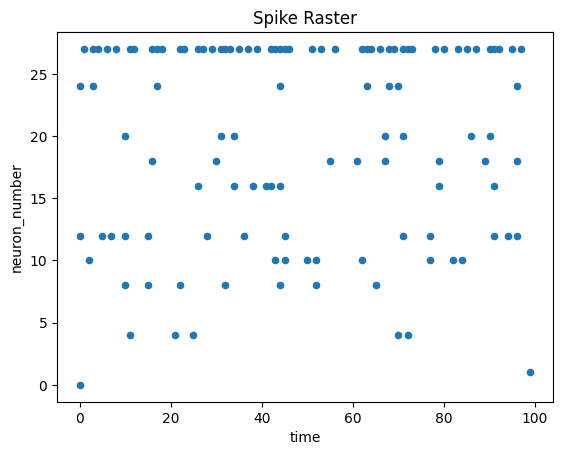

In [ ]:
vi_brick = Vector_Input(input_spikes, coding='Raster', name='Input0',time_dimension=True)
rp_brick = Projection(name='RP', output_size = 1, connection_sparsity = 1, learning = 1)
scaffold = Scaffold()
scaffold.add_brick(vi_brick )
scaffold.add_brick(rp_brick, output=True)
scaffold.connect(vi_brick, rp_brick)
scaffold.lay_bricks()
edge_weights = [scaffold.graph.edges[v]['weight'] for v in scaffold.graph.edges()]
print ('Edge weights: ', edge_weights)
backend.compile(scaffold, backend_args)
output_ports_dictionary = backend.run(n_bins)

plot_spike_raster(scaffold, output_ports_dictionary)